In [1]:
%matplotlib widget

### Imports 😎

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pbl import PreferenceBasedLearning
from feedback import SimulatedFeedback, SimulatedObjective
from gp import BasicGP
from sampler import RandomSampler

In [10]:
x = np.array([[1, 0],
              [2, 3],
              [4, 5]])
y = np.array([[1, 1],
              [2, 3],
              [4, 5]])
[1,0] == y

array([[ True, False],
       [False, False],
       [False, False]])

In [12]:
x = np.array([4, 5, 3, 2, 1])
y = np.array([1, 2, 3, 4, 5])
# Perform the comparison using broadcasting
result = x == y[:, None]


print(result.astype(int))
# print(y[:, None])

[[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 1 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]]


In [18]:
x = np.array([[1, 0],
                [2, 3],
                [4, 5]])
[2, 1] * x

array([[2, 0],
       [4, 3],
       [8, 5]])

In [6]:
np.diag([1,2])

array([[1, 0],
       [0, 2]])

# 2D Objective Function Example

### Set up pyPOLAR Objects

Everything is *very* similar apart from defining the action space in the `PreferenceBasedLearning` class and in defining the `SimulatedObjective`.

In [25]:
# construct the PBL class. here, we define our action set.
pbl = PreferenceBasedLearning(low=np.array([-1,-1]),
                              high=np.array([1, 1]),
                              action_dims=np.array([20, 20]),
                              preference_noise=0.01,
                              coactive_noise=0.01,
                              ordinal_noise=0.01)

objective = SimulatedObjective(smooth=True, 
                               ord_lbls=3,
                               action_space=pbl.action_space,
                               function='2D')

# simulates feedback according to a 1D objective function
fb = SimulatedFeedback(objective=objective,
                       action_space=pbl.action_space) 

# setup the GP model
gp = BasicGP(lengthscale=1, signal_var=1)
gp.setup(pbl.action_space, pbl.overall_likelihood, None) #pbl.preference_jacobian) # assign the action space
                                                   # and likelihood function 
                                                   # from the PBL object

# setup a random sampler to sample actions during data collection
sampler = RandomSampler()


### Train the GP from simulated feedback

In [22]:
epochs = 5 # number of pairwise comparisons to collect
prev = sampler.sample(pbl.action_space)
for idx in range(epochs):
    # collect and add feedback to PBL object
    curr = sampler.sample(pbl.action_space)
    preference, coactive, ordinal = fb.evaluate(curr, prev,
                                                get_pairwise=True,
                                                get_coactive=True,
                                                get_ordinal=True)
    pbl.add_feedback(preference, coactive, ordinal)
    
# fit the model
mu = gp.fit(method='BFGS', options={'disp': False})

### Test the accuracy of the fitted model

In [23]:
predictions = 1000
correct = 0

prev = sampler.sample(pbl.action_space)
for i in range(predictions):
    # sample the next action
    curr = sampler.sample(pbl.action_space)
    pred = pbl.predict(gp.mu, curr, prev)
    (_, _, label), _, _ = fb.evaluate(curr, prev, get_pairwise=True)
    correct += int(pred == label)
    prev = curr

print(f'Accuracy: {correct / predictions * 100}%')
print('Likelihood:', pbl.overall_likelihood(gp.mu))
print('True optimal likelihood:', pbl.overall_likelihood(objective(gp.actions)))

Accuracy: 80.9%
Likelihood: 4.529867682423093
True optimal likelihood: -0.13294999215876585


### Plot the results
Things are a little more complicated since we need to make 3D plots...

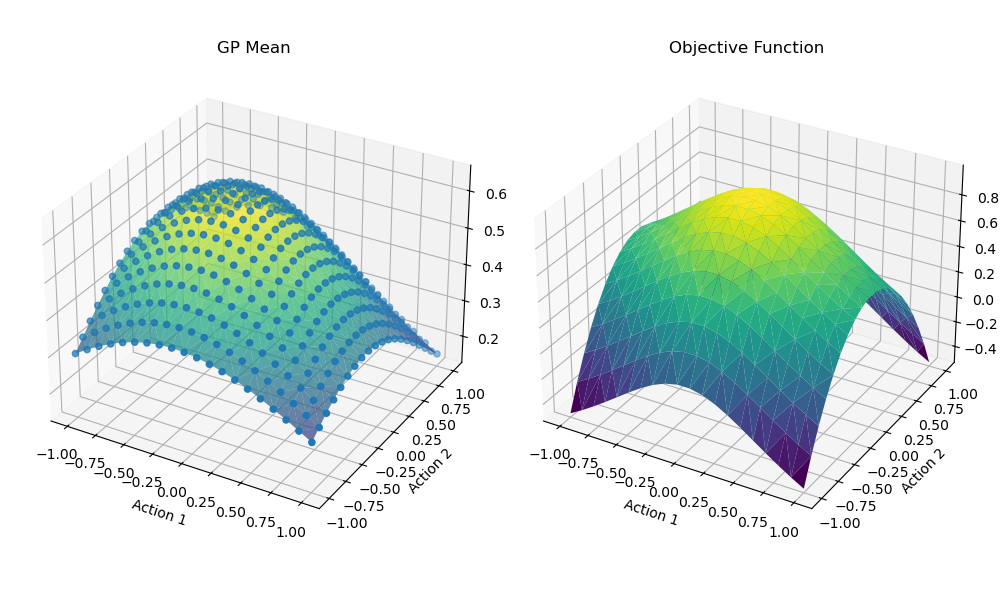

In [24]:
fig = plt.figure()
left = fig.add_subplot(121, projection='3d')
right = fig.add_subplot(122, projection='3d')

# Plot the surface
left.plot_trisurf(gp.actions[:,0], gp.actions[:, 1], gp.mu, cmap='viridis', alpha=0.75)
left.scatter(gp.actions[:,0], gp.actions[:, 1], gp.mu)
right.plot_trisurf(gp.actions[:,0], gp.actions[:, 1], objective(gp.actions), cmap='viridis')
left.set_title('GP Mean')
right.set_title('Objective Function')

for ax in [left, right]:
    ax.set_xlabel('Action 1')
    ax.set_ylabel('Action 2')
    ax.set_zlabel('Reward')
    
# Function to synchronize the rotation
def on_rotate(event):
    ax, elev, azim = None, 0, 0
    if event.inaxes == left:
        elev = left.elev
        azim = left.azim
        ax = right
    else:
        elev = right.elev
        azim = right.azim
        ax = left
    ax.view_init(elev=elev, azim=azim)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_rotate)
fig.set_size_inches((10, 6))
fig.tight_layout()
plt.show()